In [3]:
import numpy as np
import keras
import matplotlib.pyplot as plt
from keras.models import Model
from keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from keras.datasets import mnist

label  5


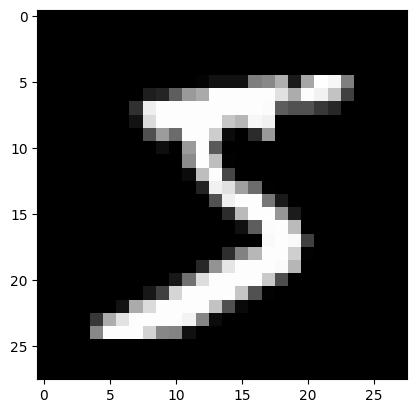

In [4]:
# Load data
(x_train,y_train), (x_test, y_test) = mnist.load_data()
# Preview
print("label ",y_train[0])
plt.imshow(x_train[0], cmap='gray')

In [5]:
# Preprocess data
# Data of type float32, models often perform better with numeric data in floating point form.
# Normalize the data to the range [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [6]:
# Convert labels into categories
# Categorical encoding (one-hot encoding) on the training label set
# Convert class labels into binary form as vectors of zeros and ones
# 3 -> [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [7]:
# Define the model using Functional API
# Conv2D(number of filters,...)
input_shape = (28, 28, 1)
inputs = Input(shape=input_shape)
x = Conv2D(4, kernel_size=(3, 3), activation='relu')(inputs) #64
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x) #128
outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)

In [8]:
# Compile the model
# 'categorical_crossentropy' average of the logarithm of predicted probabilities for the true class
# Adam optimizer utilizes adaptive moment estimation for effectively adjusting model weights during training
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train the model
# batch_size number of training samples used for one weight update of the model during one training iteration
model.fit(x_train, y_train, batch_size=128, epochs=5, verbose='auto', validation_data=(x_test, y_test))

Epoch 1/5
469/469 [==============================] - 3s 5ms/step - loss: 0.3729 - accuracy: 0.8980 - val_loss: 0.1644 - val_accuracy: 0.9518
Epoch 2/5
469/469 [==============================] - 2s 4ms/step - loss: 0.1330 - accuracy: 0.9614 - val_loss: 0.1040 - val_accuracy: 0.9700
Epoch 3/5
469/469 [==============================] - 2s 5ms/step - loss: 0.0951 - accuracy: 0.9714 - val_loss: 0.0838 - val_accuracy: 0.9750
Epoch 4/5
469/469 [==============================] - 2s 5ms/step - loss: 0.0749 - accuracy: 0.9775 - val_loss: 0.0692 - val_accuracy: 0.9780
Epoch 5/5
469/469 [==============================] - 2s 4ms/step - loss: 0.0618 - accuracy: 0.9816 - val_loss: 0.0650 - val_accuracy: 0.9797


In [9]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test, verbose='auto')
print('Test loss:', loss)
print('Test accuracy:', accuracy)

313/313 [==============================] - 1s 4ms/step - loss: 0.0650 - accuracy: 0.9797
Test loss: 0.06497687101364136
Test accuracy: 0.9797000288963318


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 26, 26, 4)         40        
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 4)         0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 676)               0         
                                                                 
 dense_3 (Dense)             (None, 64)                43328     
                                                                 
 dense_4 (Dense)             (None, 10)                650       
                                                           

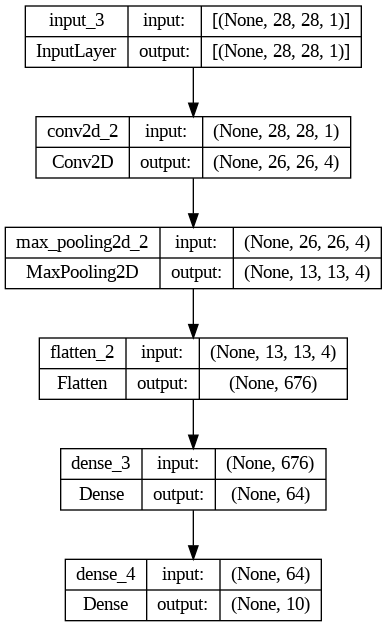

In [10]:
# Model visualization
model.summary()
plot_model(model, show_shapes=True, show_layer_names=True) # to_file='model_plot.png',

313/313 [==============================] - 1s 3ms/step
Misclassified example number 1


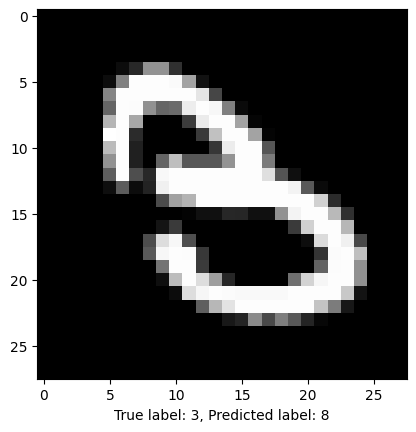

Misclassified example number 2


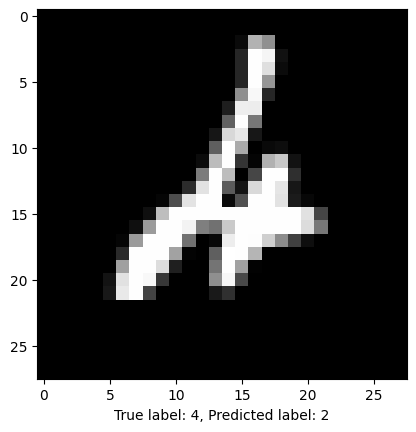

Misclassified example number 3


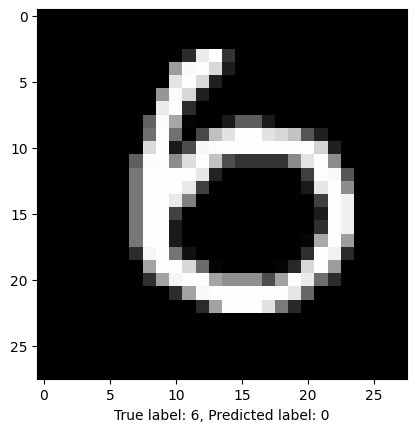

Misclassified example number 4


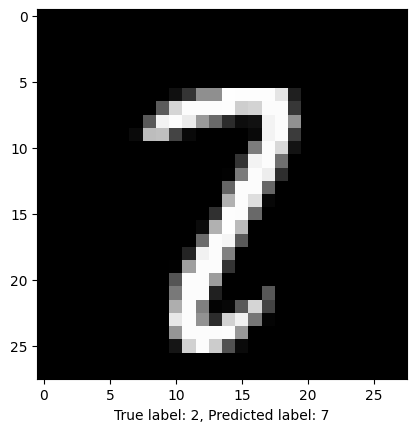

Misclassified example number 5


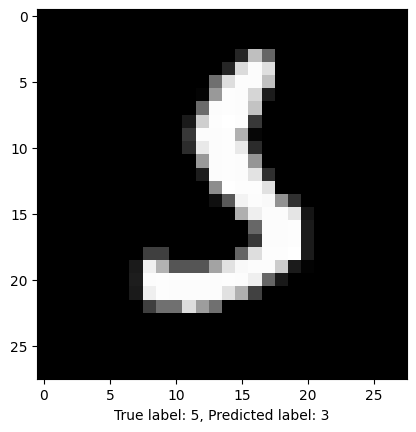

In [11]:
# Display examples of misclassified samples
predictions = model.predict(x_test)
incorrect_indices = np.nonzero(np.argmax(predictions, axis=1) != np.argmax(y_test, axis=1))[0]

for i in range(5):
    idx = incorrect_indices[i]
    print("Misclassified example number", i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.xlabel(f"True label: {np.argmax(y_test[idx])}, Predicted label: {np.argmax(predictions[idx])}")
    plt.show()